In [14]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fanalysis.ca import CA
from matplotlib.ticker import PercentFormatter

data = pd.read_csv('data.csv')

### Diagrammes en barre décrivant la proportion de chaque item en fonction de l'étape du raisonnement clinique.  

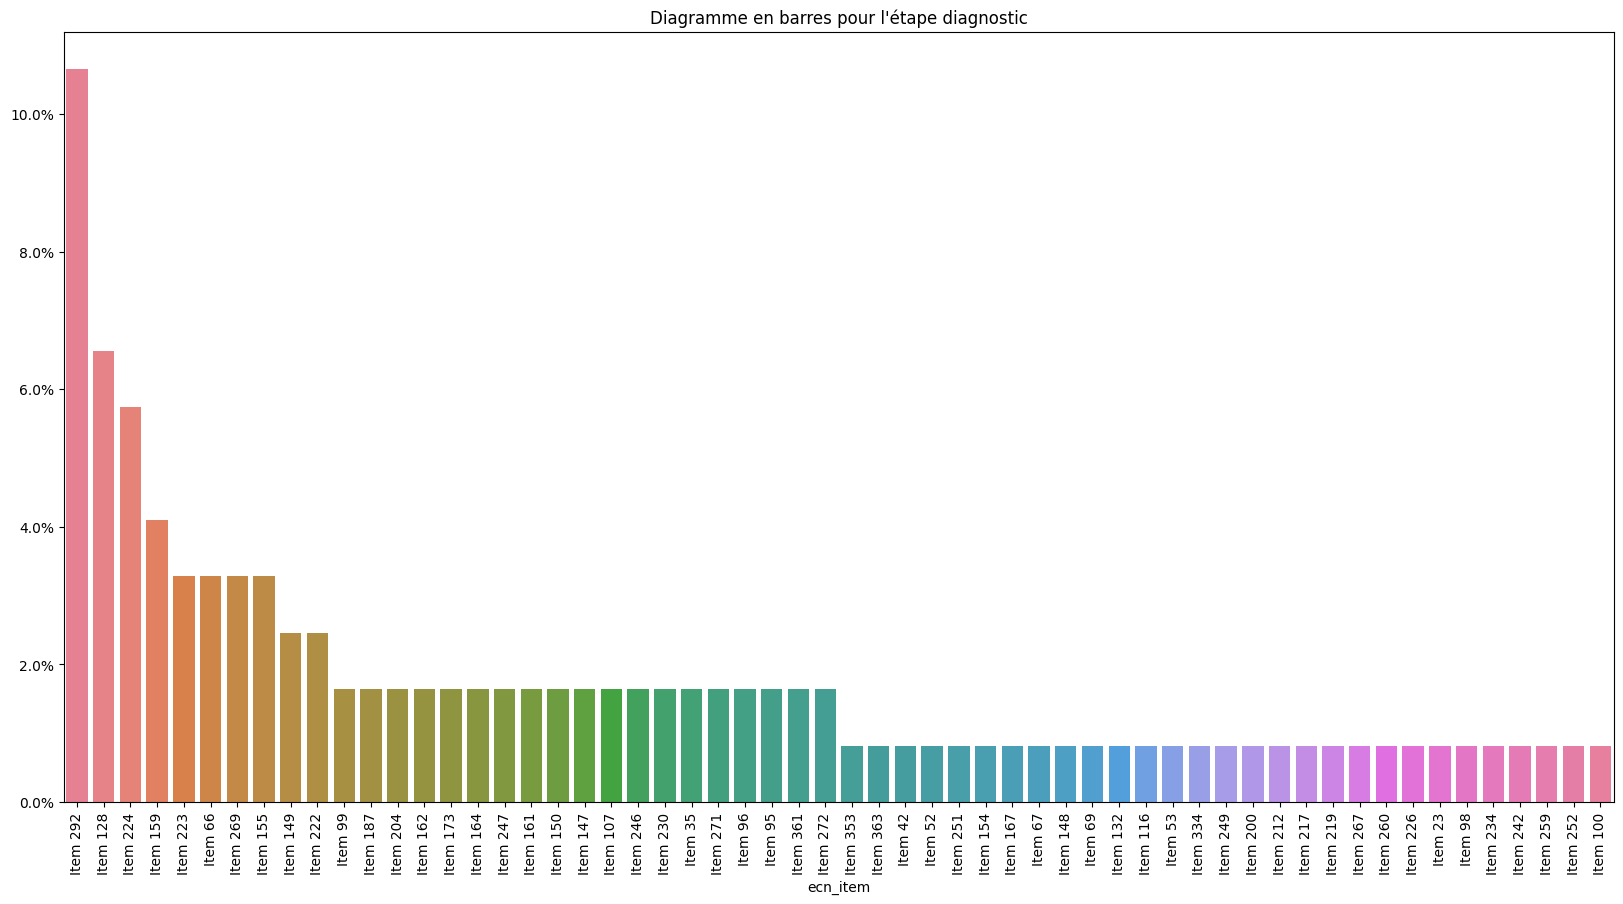

diagnostic
ecn_item    Item 292  Item 128  Item 224  Item 159  Item 223  Item 66  \
diagnostic        13         8         7         5         4        4   

ecn_item    Item 269  Item 155  Item 149  Item 222  ...  Item 267  Item 260  \
diagnostic         4         4         3         3  ...         1         1   

ecn_item    Item 226  Item 23  Item 98  Item 234  Item 242  Item 259  \
diagnostic         1        1        1         1         1         1   

ecn_item    Item 252  Item 100  
diagnostic         1         1  

[1 rows x 58 columns]


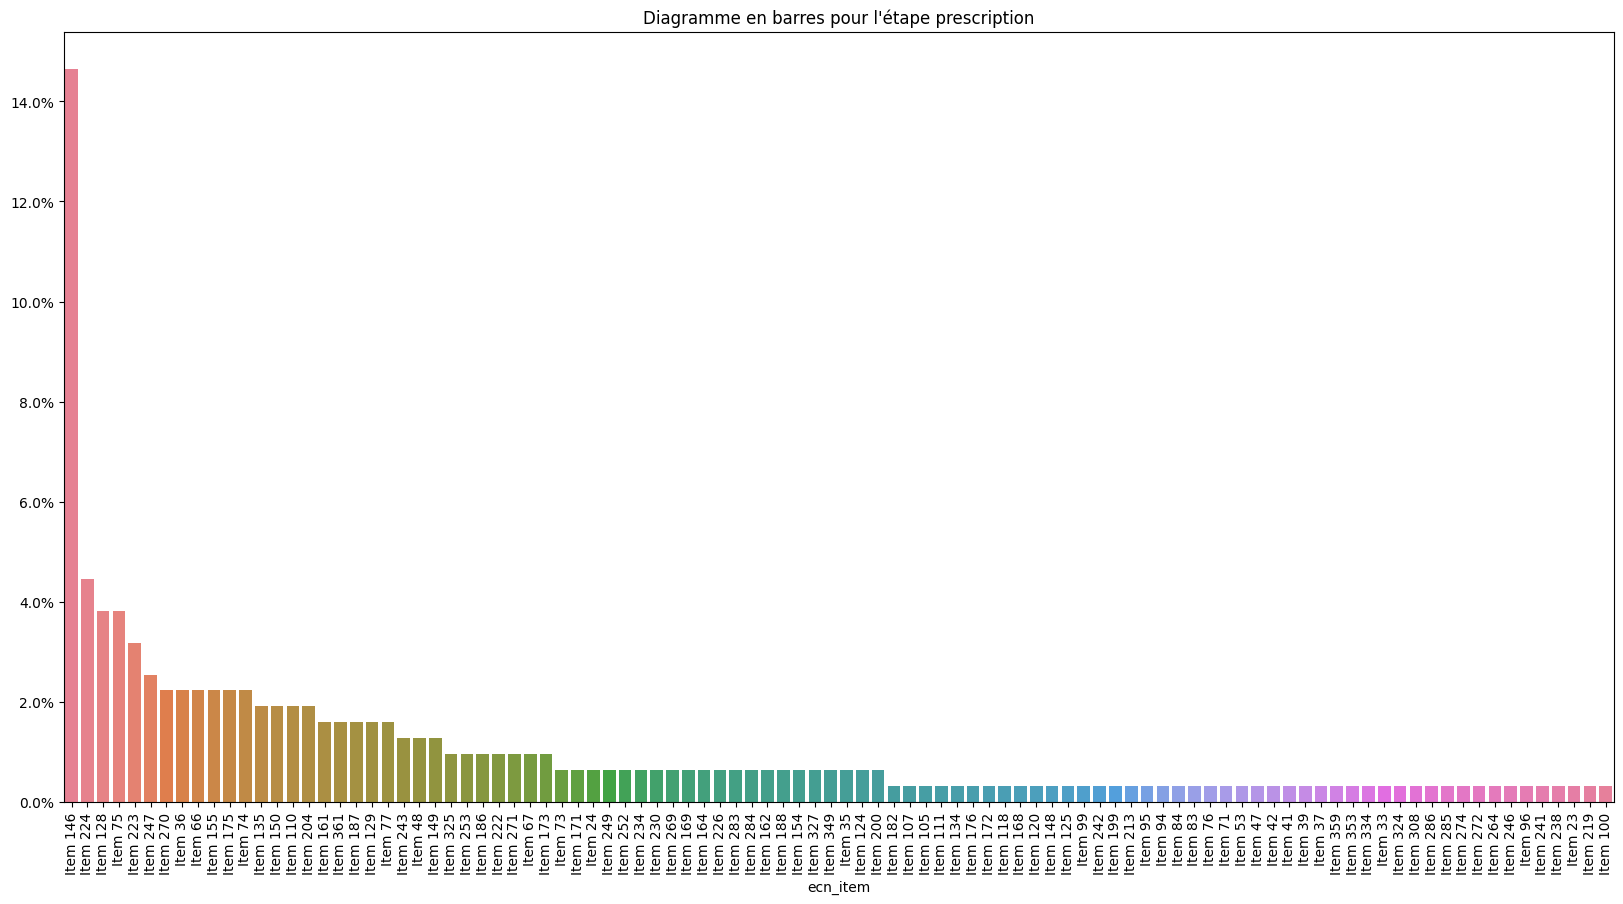

prescription
ecn_item      Item 146  Item 224  Item 128  Item 75  Item 223  Item 247  \
prescription        46        14        12       12        10         8   

ecn_item      Item 270  Item 36  Item 66  Item 155  ...  Item 274  Item 272  \
prescription         7        7        7         7  ...         1         1   

ecn_item      Item 264  Item 246  Item 96  Item 241  Item 238  Item 23  \
prescription         1         1        1         1         1        1   

ecn_item      Item 219  Item 100  
prescription         1         1  

[1 rows x 98 columns]


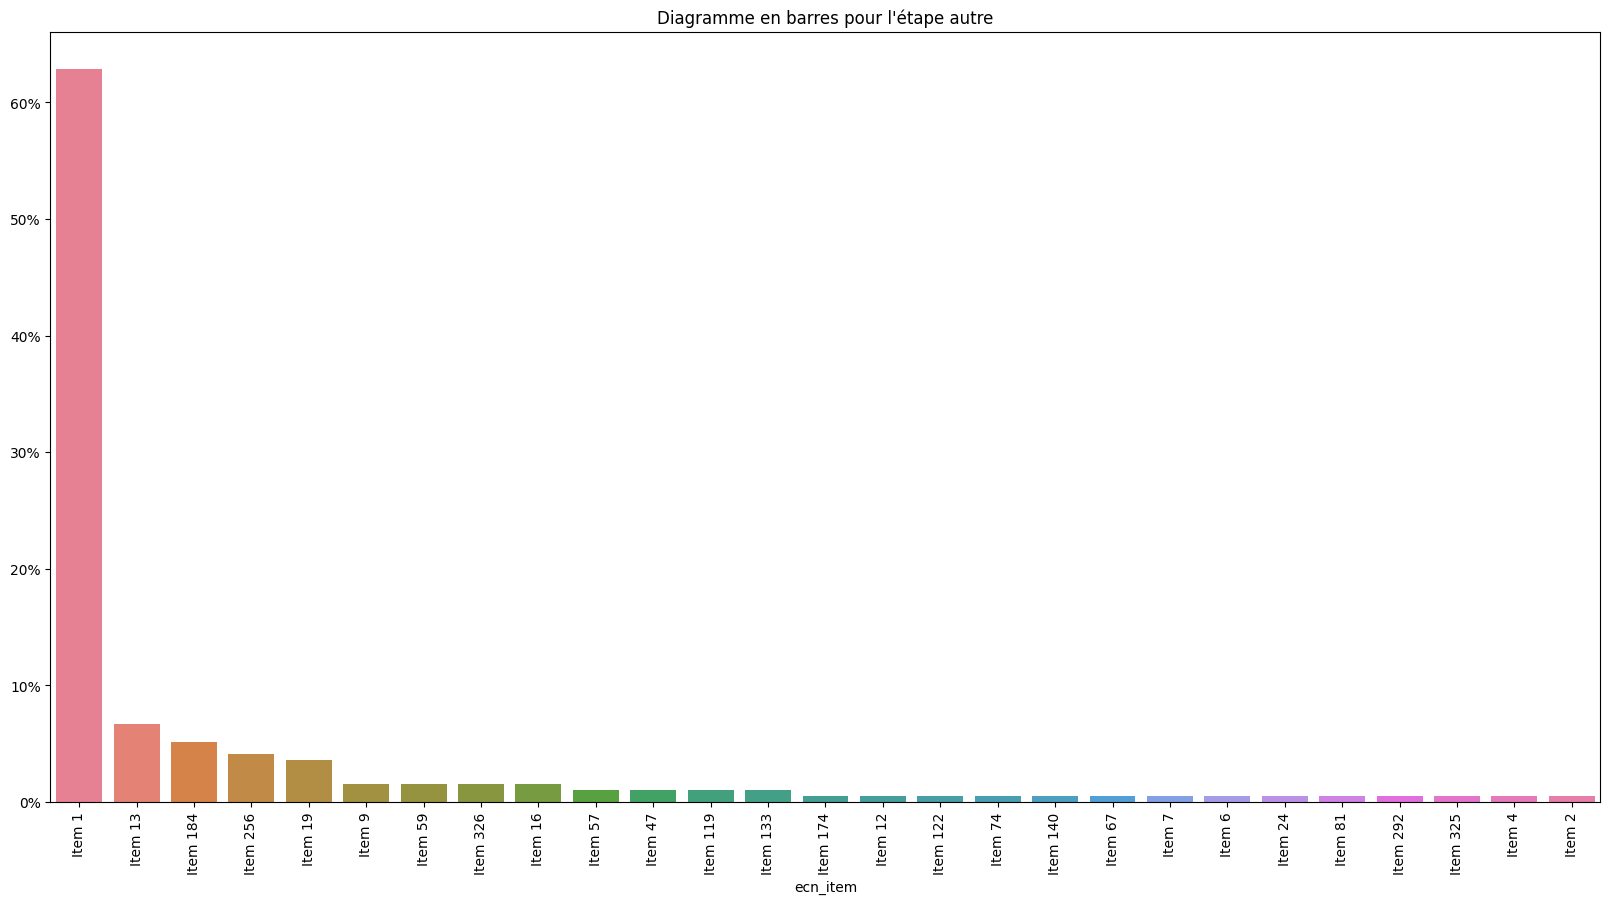

autre
ecn_item  Item 1  Item 13  Item 184  Item 256  Item 19  Item 9  Item 59  \
autre        122       13        10         8        7       3        3   

ecn_item  Item 326  Item 16  Item 57  ...  Item 140  Item 67  Item 7  Item 6  \
autre            3        3        2  ...         1        1       1       1   

ecn_item  Item 24  Item 81  Item 292  Item 325  Item 4  Item 2  
autre           1        1         1         1       1       1  

[1 rows x 27 columns]


In [16]:
data_gpByItem = data.groupby(['ecn_item']).agg(
    diagnostic = ('step_diag', 'sum'),
    prescription = ('step_PEC_TTT', 'sum'), 
    autre = ('step_autre', 'sum')
)

data_gpByItem = data_gpByItem.transpose()

for i in range(0,data_gpByItem.shape[0]):
    row = data_gpByItem.iloc[[i]]
    row = row.dropna(axis=1, how='all')
    row = row.loc[:, row.iloc[0] != 0]
    row = row[row.columns[row.iloc[0].argsort()[::-1]]]

    rowProp = row.copy()
    rowProp[row.columns] = row[row.columns].div(row[row.columns].sum(axis=1), axis=0)

    plt.figure(figsize=(20, 10))
    sns.barplot(rowProp)
    plt.xticks(rotation=90)
    plt.title(f"Diagramme en barres pour l'étape {data_gpByItem.index[i]}")
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.show()  
    print(data_gpByItem.index[i])
    print(row)
